In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pickle

In [32]:
data=pd.read_csv("loan_prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001316,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban,Y
1,LP001387,Female,Yes,0,Graduate,NaN,2929,2333.0,139.0,360.0,1.0,Semiurban,Y
2,LP001157,Female,No,0,Graduate,No,3086,0.0,120.0,360.0,1.0,Semiurban,Y
3,LP002297,Male,No,0,Graduate,No,2500,20000.0,103.0,360.0,1.0,Semiurban,Y
4,LP002141,Male,Yes,3+,Graduate,No,2666,2083.0,95.0,360.0,1.0,Rural,Y


In [33]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
467,LP001543,Male,Yes,1,Graduate,No,9538,0.0,187.0,360.0,1.0,Urban,Y
468,LP002255,Male,No,3+,Graduate,No,9167,0.0,185.0,360.0,1.0,Rural,Y
469,LP002619,Male,Yes,0,Not Graduate,No,3814,1483.0,124.0,300.0,1.0,Semiurban,Y
470,LP001665,Male,Yes,1,Graduate,No,3125,2583.0,170.0,360.0,1.0,Semiurban,N
471,LP001529,Male,Yes,0,Graduate,Yes,2577,3750.0,152.0,360.0,1.0,Rural,Y


In [34]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,472.000000,472.000000,458.000000,461.000000,429.000000
mean,5562.283898,1487.771017,145.628821,341.180043,0.946387
std,6580.578703,1934.875373,87.660461,62.851621,0.225516
min,210.000000,0.000000,17.000000,12.000000,0.000000
25%,2917.000000,0.000000,100.000000,360.000000,1.000000
50%,3858.500000,1128.500000,126.000000,360.000000,1.000000
75%,5823.000000,2287.750000,162.000000,360.000000,1.000000
max,81000.000000,20000.000000,700.000000,480.000000,1.000000


In [35]:
data.drop("Loan_ID",axis=1,inplace=True)

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472 entries, 0 to 471
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             464 non-null    object 
 1   Married            469 non-null    object 
 2   Dependents         461 non-null    object 
 3   Education          472 non-null    object 
 4   Self_Employed      446 non-null    object 
 5   ApplicantIncome    472 non-null    int64  
 6   CoapplicantIncome  472 non-null    float64
 7   LoanAmount         458 non-null    float64
 8   Loan_Amount_Term   461 non-null    float64
 9   Credit_History     429 non-null    float64
 10  Property_Area      472 non-null    object 
 11  Loan_Status        472 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 44.4+ KB


In [37]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban,Y
1,Female,Yes,0,Graduate,NaN,2929,2333.0,139.0,360.0,1.0,Semiurban,Y
2,Female,No,0,Graduate,No,3086,0.0,120.0,360.0,1.0,Semiurban,Y
3,Male,No,0,Graduate,No,2500,20000.0,103.0,360.0,1.0,Semiurban,Y
4,Male,Yes,3+,Graduate,No,2666,2083.0,95.0,360.0,1.0,Rural,Y


In [38]:
data[["Gender","Married","Dependents","Education","Self_Employed","Property_Area","Loan_Status"]].nunique()

Gender           2
Married          2
Dependents       4
Education        2
Self_Employed    2
Property_Area    3
Loan_Status      2
dtype: int64

In [39]:
data["Loan_Status"].unique()

array(['Y', 'N'], dtype=object)

In [40]:
data["Dependents"]=pd.to_numeric(data["Dependents"],errors='coerce')
data["Dependents"].fillna(data["Dependents"].mode()[0],inplace=True)
data["Dependents"]=data["Dependents"].replace("3+",3)
data["Dependents"]=data["Dependents"].astype(int)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5840\3407969630.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Dependents"].fillna(data["Dependents"].mode()[0],inplace=True)


In [41]:
data.replace({
    "Male":1,"Female":0,
    "Yes":1,"No":0,
    "Graduate":1,"Not Graduate":0,
    "Urban":2,"Semiurban":1,"Rural":0,
    "Y":1,"N":0
},inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5840\574917276.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472 entries, 0 to 471
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             464 non-null    float64
 1   Married            469 non-null    float64
 2   Dependents         472 non-null    int64  
 3   Education          472 non-null    int64  
 4   Self_Employed      446 non-null    float64
 5   ApplicantIncome    472 non-null    int64  
 6   CoapplicantIncome  472 non-null    float64
 7   LoanAmount         458 non-null    float64
 8   Loan_Amount_Term   461 non-null    float64
 9   Credit_History     429 non-null    float64
 10  Property_Area      472 non-null    int64  
 11  Loan_Status        472 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 44.4 KB


In [43]:
data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)
data["Married"].fillna(data["Married"].mode()[0],inplace=True)
data["Dependents"].fillna(data["Dependents"].mode(),inplace=True)
data["Self_Employed"].fillna(data["Self_Employed"].mean(),inplace=True)
data["Loan_Amount_Term"].fillna(data["Loan_Amount_Term"].mean(),inplace=True)
data["Credit_History"].fillna(data["Credit_History"].mean(),inplace=True)
data["LoanAmount"].fillna(data["LoanAmount"].mean(),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5840\2555754219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Gender"].fillna(data["Gender"].mode()[0],inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5840\2555754219.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [44]:
data.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

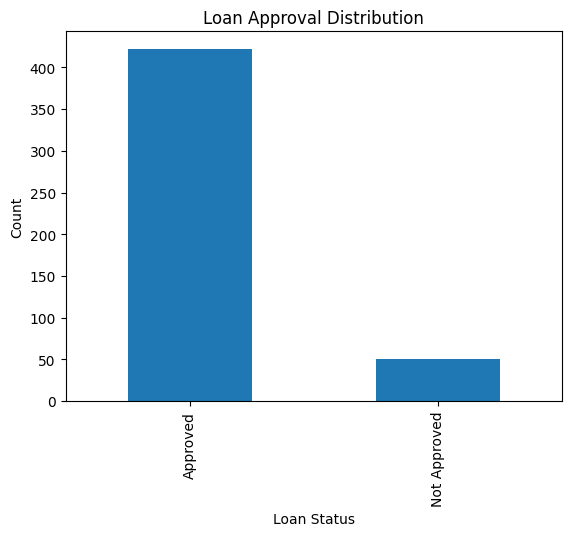

In [45]:
#Target distribution:
data["Loan_Status_Label"]=data["Loan_Status"].map({
    0:"Not Approved",
    1:"Approved"
})
data["Loan_Status_Label"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

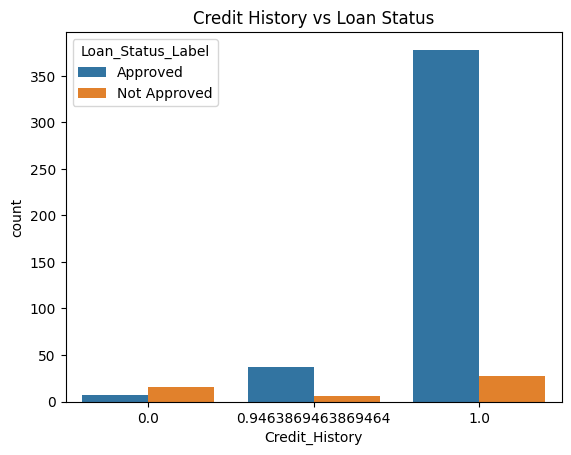

In [46]:
#Credit History Impact:
data["Loan_Status_Label"]=data["Loan_Status"].map({
    0:"Not Approved",
    1:"Approved"
})
sns.countplot(x="Credit_History",hue="Loan_Status_Label",data=data)
plt.title("Credit History vs Loan Status")
plt.show()

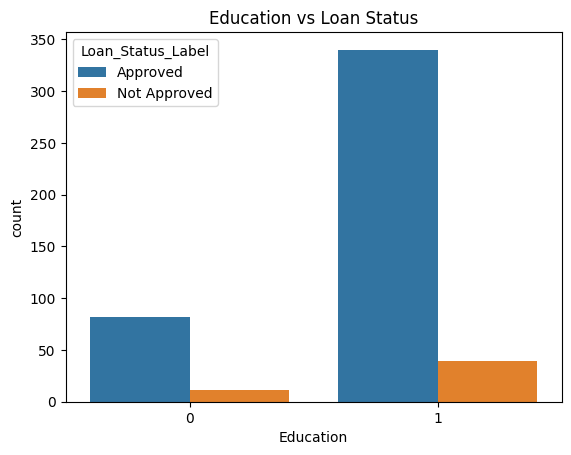

In [47]:
#Education vs Loan Status
data["Loan_Status_Label"]=data["Loan_Status"].map({
    0:"Not Approved",
    1:"Approved"
})
sns.countplot(x="Education",hue="Loan_Status_Label",data=data)
plt.title("Education vs Loan Status")
plt.show()

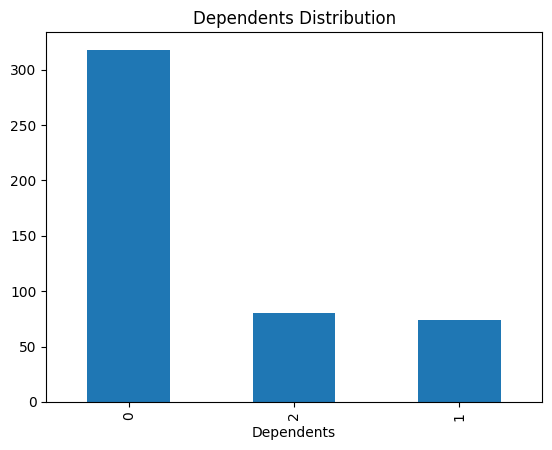

In [48]:
#Dependents Distribution:
data["Dependents"].value_counts().plot(kind="bar")
plt.title("Dependents Distribution")
plt.show()

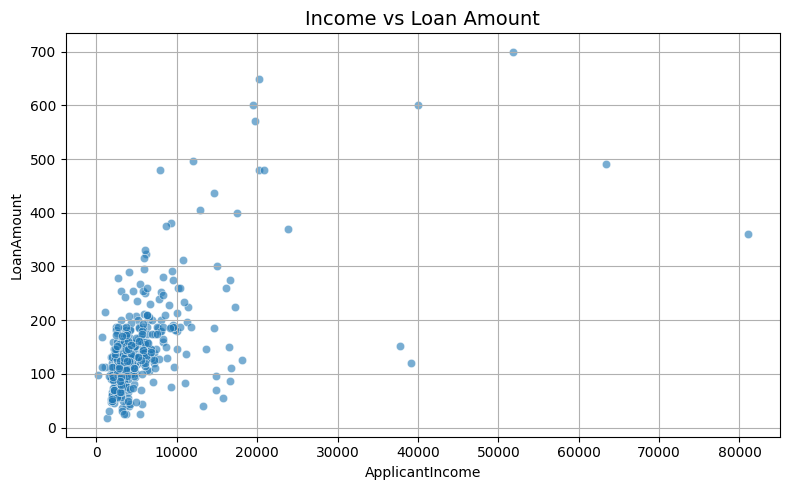

In [49]:
#Income vs Loan Amount:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data["ApplicantIncome"],y=data["LoanAmount"],alpha=0.6)
plt.title("Income vs Loan Amount",fontsize=14)
plt.xlabel("ApplicantIncome")
plt.ylabel("LoanAmount")
plt.grid(True)
plt.tight_layout()
plt.show()

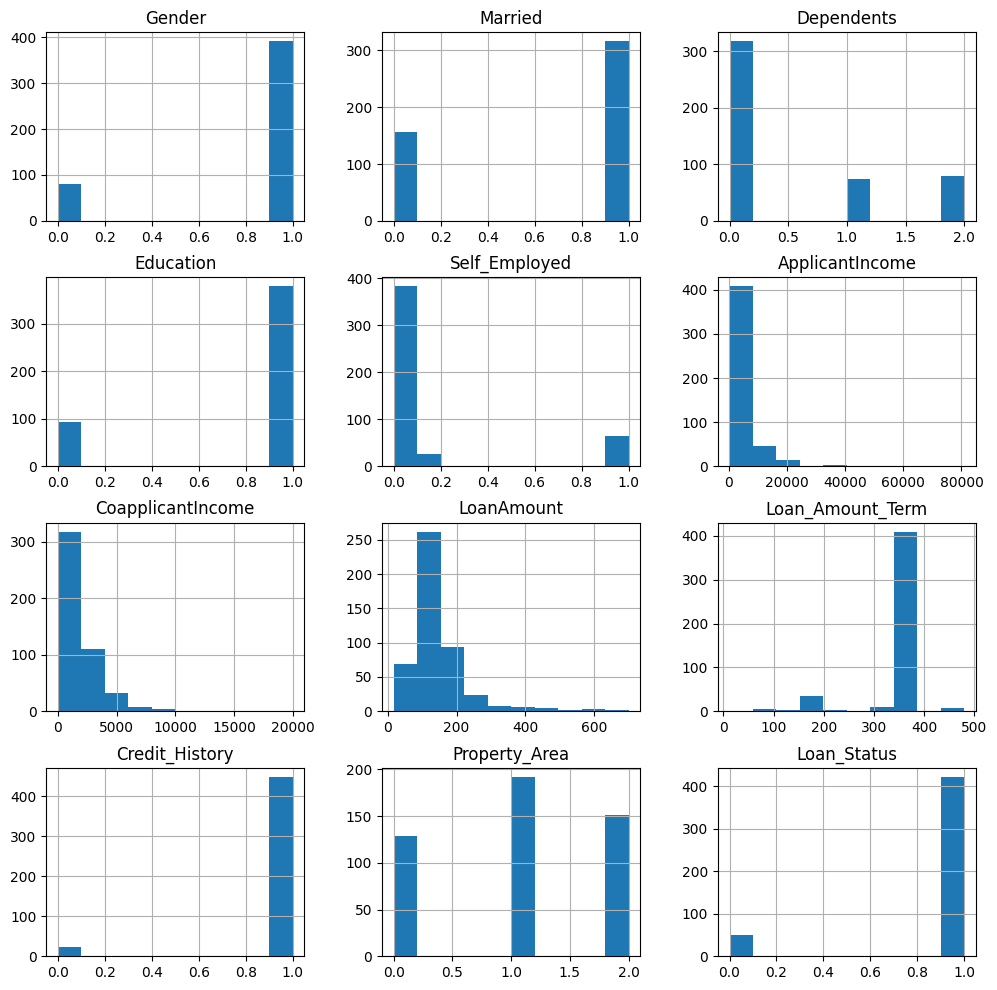

In [50]:
data.hist(figsize=(12,12),bins=10)
plt.show()

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472 entries, 0 to 471
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             472 non-null    float64
 1   Married            472 non-null    float64
 2   Dependents         472 non-null    int64  
 3   Education          472 non-null    int64  
 4   Self_Employed      472 non-null    float64
 5   ApplicantIncome    472 non-null    int64  
 6   CoapplicantIncome  472 non-null    float64
 7   LoanAmount         472 non-null    float64
 8   Loan_Amount_Term   472 non-null    float64
 9   Credit_History     472 non-null    float64
 10  Property_Area      472 non-null    int64  
 11  Loan_Status        472 non-null    int64  
 12  Loan_Status_Label  472 non-null    object 
dtypes: float64(7), int64(5), object(1)
memory usage: 48.1+ KB


In [52]:
data.drop("Loan_Status_Label",axis=1,inplace=True)

In [53]:
x=data.drop("Loan_Status",axis=1)
y=data["Loan_Status"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)
lr_acc=accuracy_score(y_test,lr_pred)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
rf_acc=accuracy_score(y_test,rf_pred)

In [56]:
svm=SVC(probability=True)
svm.fit(x_train,y_train)
svm_pred=svm.predict(x_test)
svm_acc=accuracy_score(y_test,svm_pred)

In [57]:
print("Logistic_Regression accuracy:",lr_acc)
print("Random_Forest accuracy:",rf_acc)
print("SVM accuracy:",svm_acc)

Logistic_Regression accuracy: 0.8842105263157894
Random_Forest accuracy: 0.9052631578947369
SVM accuracy: 0.9052631578947369


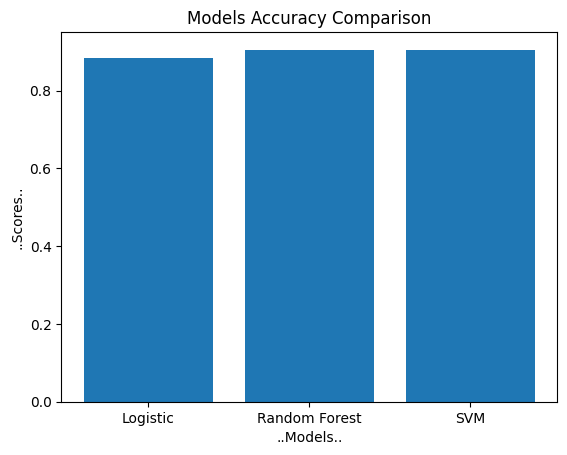

In [58]:
models=["Logistic","Random Forest","SVM"]
scores=[lr_acc,rf_acc,svm_acc]

plt.figure()
plt.bar(models,scores)
plt.title("Models Accuracy Comparison")
plt.xlabel("..Models..")
plt.ylabel("..Scores..")
plt.show()

In [59]:
accuracies={
    "Logistic":lr_acc,
    "Random_Forest":rf_acc,
    "SVM":svm_acc
    }
best_model_name=max(accuracies,key=accuracies.get)
print("\nBest Model:",best_model_name)

if best_model_name=="Logistic":
    best_model=lr
elif best_model_name=="Random Forest":
    best_model=rf
else:
    best_model=svm


Best Model: Random_Forest


In [60]:
with open("model.pkl","wb") as file:
    pickle.dump(best_model,file)
print("Model svaed successfully")

Model svaed successfully
